In [251]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier  # 분류 모델로 변경
from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression


import joblib

In [252]:
# 데이터 로드 및 전처리
df = pd.read_csv('dataset/heart_disease_uci_korean.csv', encoding='cp949')
df = df.drop(columns=['주요 혈관 수', '심장 혈류 상태'])  # 결측이 과도한 컬럼 삭제

# 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 임상적으로 0이 나올 수 없는 값은 '미기록·결측'으로 간주 (UCI 심장 데이터 관행)
# ※ 운동 후 심전도 저하(oldpeak)=0 은 '저하 없음'으로 의미가 있을 수 있어 여기서 지우지 않음
cols_zero_as_missing = ['안정 시 혈압', '콜레스테롤', '최대 심박수']
for col in cols_zero_as_missing:
    if col in df.columns:
        df.loc[df[col] == 0, col] = np.nan

In [253]:
# 결측치 처리
label_col = '심장병 진단 결과'
if label_col in df.columns:
    df = df.dropna(subset=[label_col])

# 수치형: 중앙값(이상치에 덜 민감). 라벨 열은 평균/중앙값으로 채우지 않음
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    if col == label_col:
        continue
    df[col] = df[col].fillna(df[col].median())

# 문자열: 최빈값
object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    if col == label_col:
        continue
    mode_val = df[col].mode()
    if len(mode_val) > 0:
        df[col] = df[col].fillna(mode_val.iloc[0])

# fillna 후 일부 열이 bool로 바뀌면 라벨 인코딩에서 빠질 수 있음 → 문자열 고정
for col in ('공복 혈당 여부', '운동 유발성 협심증'):
    if col in df.columns:
        df[col] = df[col].astype(str)

C:\Users\human-27\AppData\Local\Temp\ipykernel_33844\3201792816.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(mode_val.iloc[0])


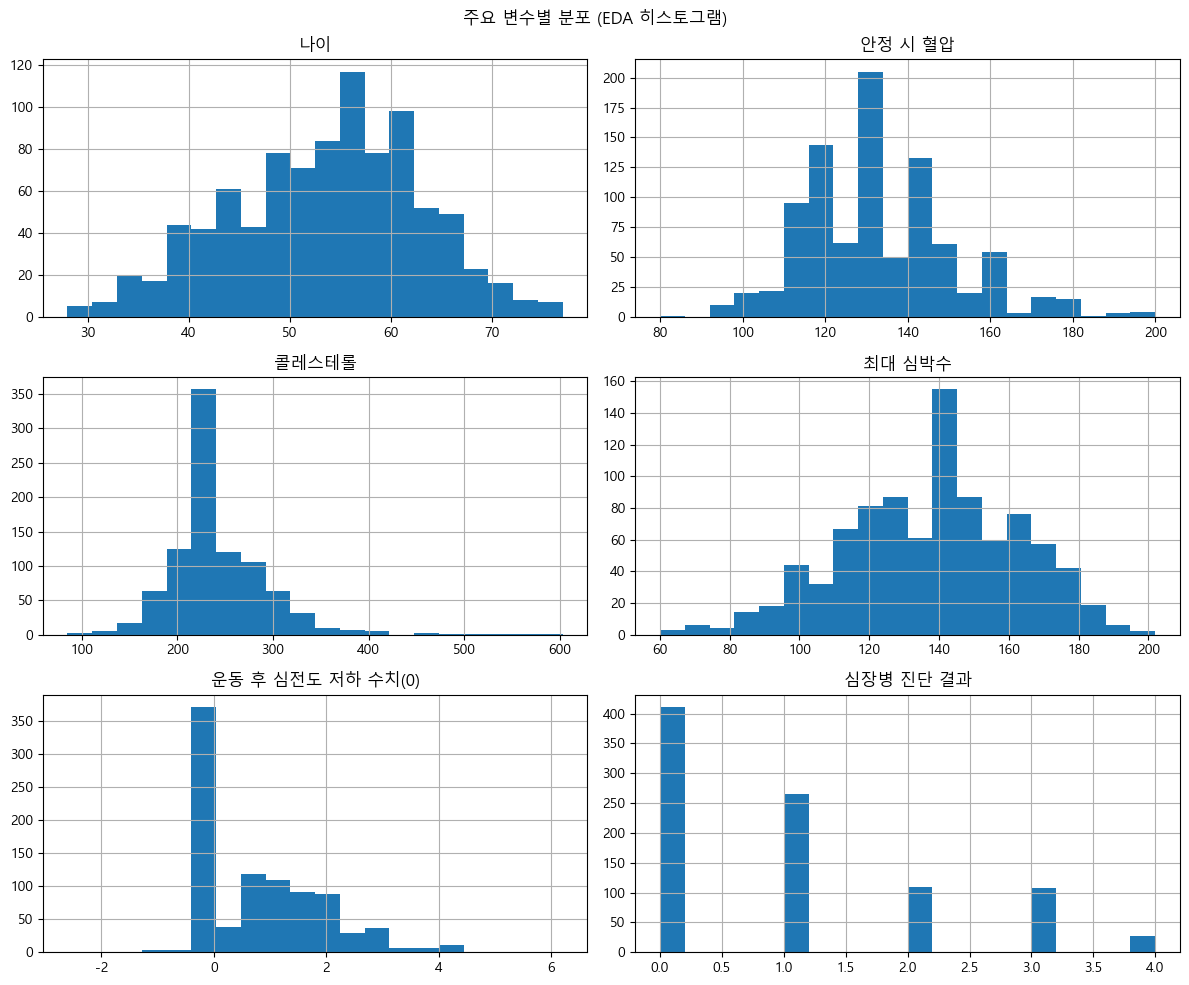

In [254]:
# 수치형 변수들이 정규분포를 따르는지 확인하는 절차 
eda_numeric = [c for c in df.select_dtypes(include=['number']).columns if c != 'target']
df[eda_numeric].hist(figsize=(12, 10), bins=20)
plt.suptitle('주요 변수별 분포 (EDA 히스토그램)')
plt.tight_layout()
plt.show()

In [255]:
# Feature Engineering
# 나이 대비 혈압 비율
df['나이 대비 혈압 비율'] = df['안정 시 혈압'] / df['나이']
# 고령자 여부 (60세 이상)
df['고령자 여부'] = (df['나이'] >= 60).astype(int)
# 최대 심박수 대비 현재 혈압 비율
df['최대 심박수 대비 현재 혈압 비율'] = df['최대 심박수'] / df['안정 시 혈압']

# inf/NaN은 파생변수에만 중앙값 보정 (전체 df에 0으로 채우면 콜레스테롤 등이 다시 '가짜 0'이 됨)
for _col in ['나이 대비 혈압 비율', '최대 심박수 대비 현재 혈압 비율']:
    df[_col] = df[_col].replace([np.inf, -np.inf], np.nan)
    df[_col] = df[_col].fillna(df[_col].median())

# 타겟 변수 이진화 (0: 정상, 1: 질환)
df['target'] = (df['심장병 진단 결과'] > 0).astype(int)

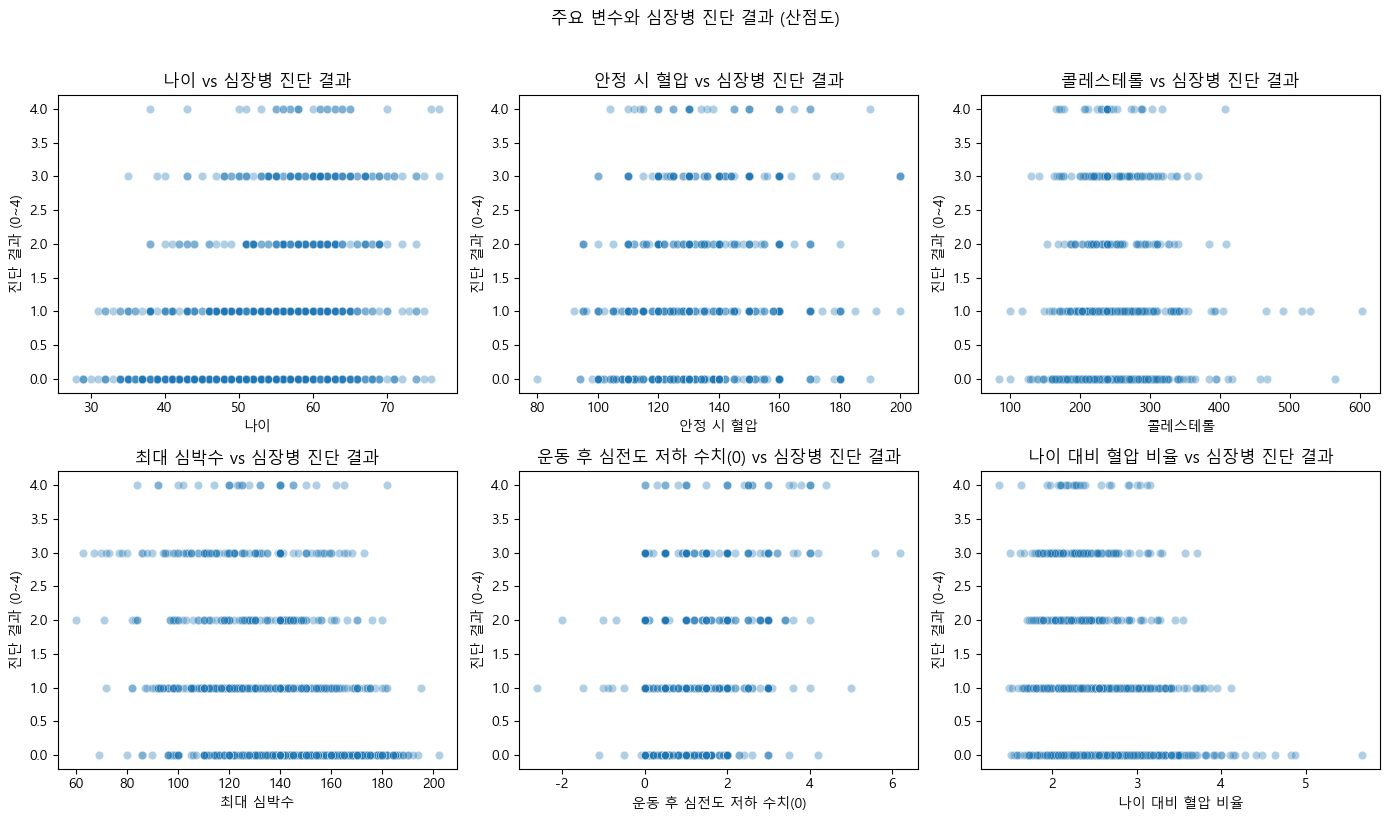

In [256]:
# y축: 심장병 진단 결과(0~4) — 단계가 보이도록. 이진 target만 쓸 때는 아래 대안 주석 참고.
scatter_x = [
    '나이',
    '안정 시 혈압',
    '콜레스테롤',
    '최대 심박수',
    '운동 후 심전도 저하 수치(0)',
    '나이 대비 혈압 비율',
]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, scatter_x):
    sns.scatterplot(
        data=df,
        x=col,
        y='심장병 진단 결과',
        alpha=0.35,
        ax=ax,
    )
    ax.set_title(f'{col} vs 심장병 진단 결과')
    ax.set_ylabel('진단 결과 (0~4)')
plt.suptitle('주요 변수와 심장병 진단 결과 (산점도)', y=1.02)
plt.tight_layout()
plt.show()

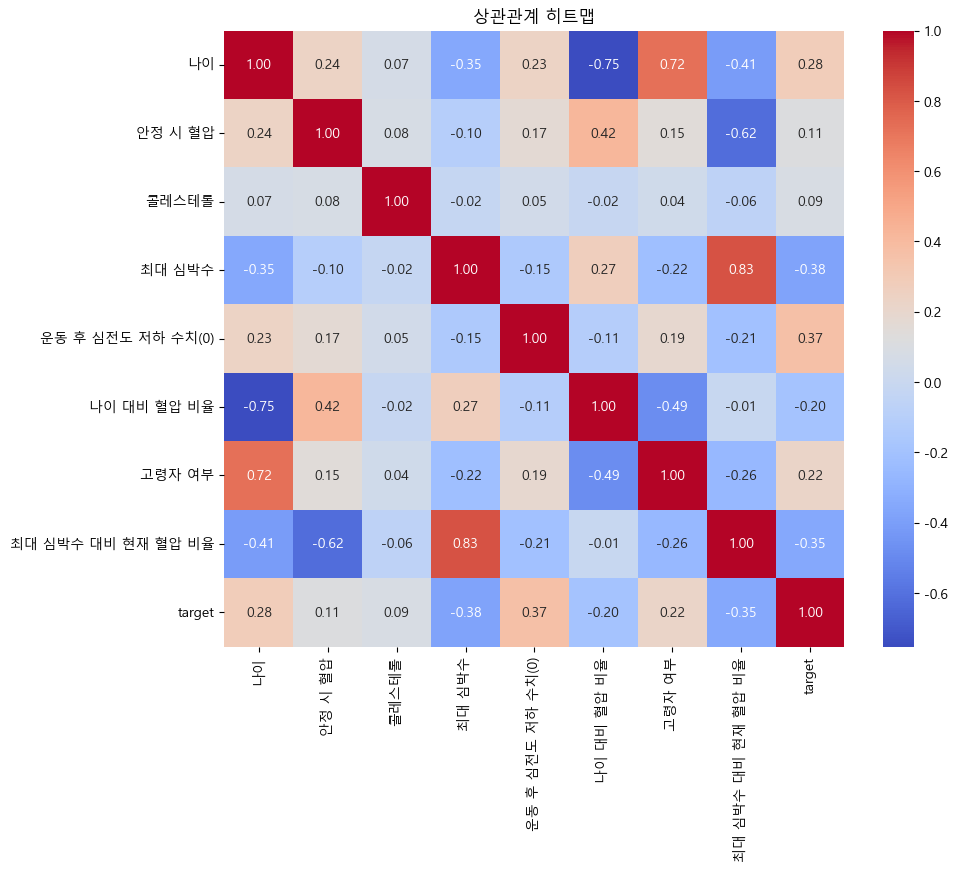

In [257]:
# 히트맵 분석 (타겟은 target만 — 심장병 진단 결과 열은 상관행렬에서 제외)
plt.figure(figsize=(10, 8))
exclude_from_corr = {'심장병 진단 결과'}
numeric_cols = [c for c in df.select_dtypes(include=['number']).columns if c not in exclude_from_corr]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('상관관계 히트맵')
plt.show()

In [258]:
# 라벨 인코딩 
categorical_cols = df.select_dtypes(include=['object']).columns
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [259]:
# Feature/Target X, y 분리
# 원본 타겟과 파생 타겟을 제외한 나머지를 X로
X = df.drop(['심장병 진단 결과', 'target'], axis=1)
y = df['target']

In [260]:
# 데이터 분할 (정확하게 정답 컬럼들만 제외)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [261]:
# 스케일링 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


 로직스틱 회귀 정확도: 0.7880, 재현율: 0.8333, F1 점수: 0.8134
              precision    recall  f1-score   support

           0       0.78      0.73      0.75        82
           1       0.79      0.83      0.81       102

    accuracy                           0.79       184
   macro avg       0.79      0.78      0.78       184
weighted avg       0.79      0.79      0.79       184


 의사결정 나무 정확도: 0.7663, 재현율: 0.7843, F1 점수: 0.7882
              precision    recall  f1-score   support

           0       0.73      0.74      0.74        82
           1       0.79      0.78      0.79       102

    accuracy                           0.77       184
   macro avg       0.76      0.76      0.76       184
weighted avg       0.77      0.77      0.77       184


 랜덤 트리 정확도: 0.7717, 재현율: 0.8235, F1 점수: 0.8000
              precision    recall  f1-score   support

           0       0.76      0.71      0.73        82
           1       0.78      0.82      0.80       102

    accuracy                      

,정확도(Accuracy),재현율(Recall),F1(F1-score)
모델,,,
로직스틱 회귀,0.788043,0.833333,0.813397
의사결정 나무,0.766304,0.784314,0.788177
랜덤 트리,0.771739,0.823529,0.800000
XGBoost,0.782609,0.823529,0.807692


<Figure size 1200x500 with 0 Axes>

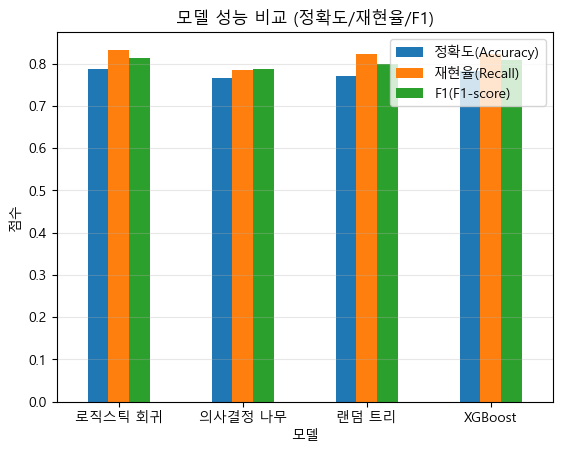

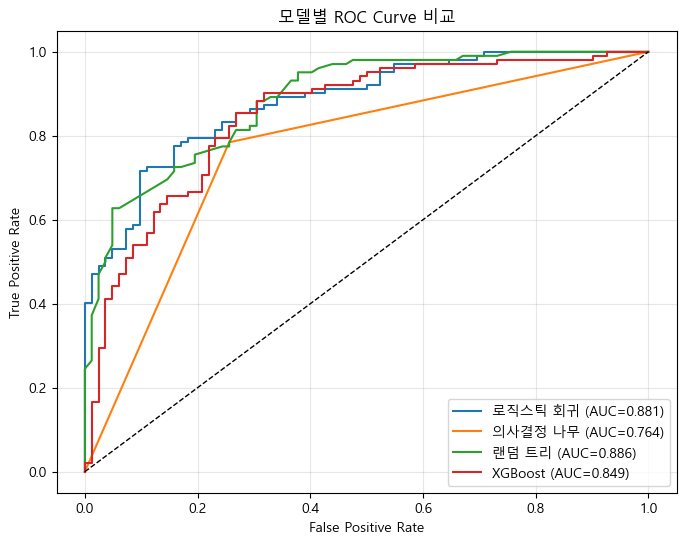

In [ ]:
# 모델 비교 (그래프 + 지표)

models = {
    "로직스틱 회귀": LogisticRegression(max_iter=1000),
    "의사결정 나무": DecisionTreeClassifier(random_state=42),
    "랜덤 포레스트": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42),
}

results = []
roc_curves = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "모델": name,
        "정확도(Accuracy)": acc,
        "재현율(Recall)": recall,
        "F1(F1-score)": f1,
    })

    print(f"\n {name} 정확도: {acc:.4f}, 재현율: {recall:.4f}, F1 점수: {f1:.4f}")
    print(classification_report(y_test, y_pred))
    print("=" * 50)

    # ROC 계산 (predict_proba 지원 모델 기준)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        roc_curves[name] = (fpr, tpr, auc)

# 1) 지표 비교 막대그래프
res_df = pd.DataFrame(results).set_index("모델")
display(res_df)

plt.figure(figsize=(12, 5))
res_df[["정확도(Accuracy)", "재현율(Recall)", "F1(F1-score)" ]].plot(kind="bar")
plt.title("모델 성능 비교 (정확도/재현율/F1)")
plt.ylabel("점수")
plt.xticks(rotation=0)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# 2) ROC Curve 비교
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("모델별 ROC Curve 비교")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [263]:

# 모델 정의 
lr_model = LogisticRegression(random_state=42, max_iter=5000)
lr_model.fit(X_train_scaled, y_train)


# 하이퍼파라미터 그리드 설정
# C는 규제 강도: 작을수록 강한 규제(모델이 단순해짐), 클수록 약한 규제(데이터에 밀착)
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"], # 로지스틱 회귀의 표준 규제 방식
    "solver": ["lbfgs"], # 소규모 데이터셋에 최적화된 계산 엔진
}

# GridSearchCV 실행
grid = GridSearchCV(
    lr_model,          # 학습할 모델
    param_grid,       # 시도할 파라미터 조합
    cv=5,             # 5-폴드 교차 검증 (데이터를 5등분해서 돌려막기 학습)
    scoring="recall",     
    n_jobs=-1,        # 내 컴퓨터의 모든 코어(CPU)를 사용하여 병렬 연산
    refit=True,       # 가장 좋은 파라미터로 전체 데이터를 다시 학습
)

# 최적의 조합 찾기 시작
grid.fit(X_train_scaled, y_train)

# 결과 출력
print(f"GridSearchCV 최적 하이퍼파라미터: {grid.best_params_}")
print(f"교차검증 최고 recall 점수: {grid.best_score_:.4f}")

# 최적 모델로 예측 및 최종 평가
best_lr = grid.best_estimator_
y_pred = best_lr.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n[테스트 세트] 최적 모델 성능 - 정확도: {acc:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}")
print("-" * 60)
print(classification_report(y_test, y_pred))

GridSearchCV 최적 하이퍼파라미터: {'C': 0.001, 'penalty': 'l2', 'solver': 'lbfgs'}
교차검증 최고 recall 점수: 0.8869

[테스트 세트] 최적 모델 성능 - 정확도: 0.7554, 재현율: 0.8824, F1: 0.8000
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.80      0.60      0.69        82
           1       0.73      0.88      0.80       102

    accuracy                           0.76       184
   macro avg       0.77      0.74      0.74       184
weighted avg       0.76      0.76      0.75       184



Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

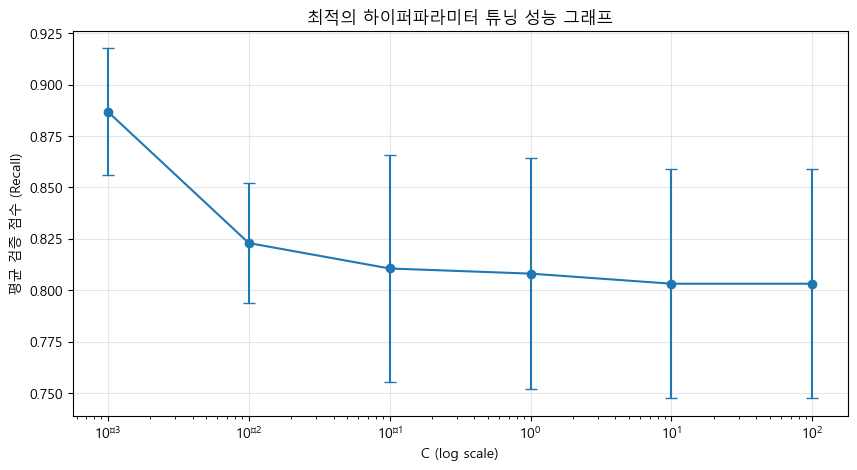

상위 5개 파라미터 조합:


,param_C,mean_test_score,std_test_score
0,0.001,0.886871,0.030804
1,0.010,0.822975,0.029259
2,0.100,0.810599,0.055333
3,1.000,0.808100,0.056014
4,10.000,0.803192,0.055742


In [264]:
# [시각화] GridSearchCV 튜닝 과정 그래프 (C 값별 평균 검증 점수)
cv_df = pd.DataFrame(grid.cv_results_)
cv_df['param_C'] = cv_df['param_C'].astype(float)
cv_df = cv_df.sort_values('param_C')

plt.figure(figsize=(10, 5))
plt.errorbar(
    cv_df['param_C'],
    cv_df['mean_test_score'],
    yerr=cv_df['std_test_score'],
    fmt='o-',
    capsize=4
)
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('평균 검증 점수 (Recall)')
plt.title('최적의 하이퍼파라미터 튜닝 성능 그래프')
plt.grid(True, alpha=0.3)
plt.show()

print('상위 5개 파라미터 조합:')
cols = ['param_C', 'mean_test_score', 'std_test_score']
display(cv_df[cols].sort_values('mean_test_score', ascending=False).head(5))

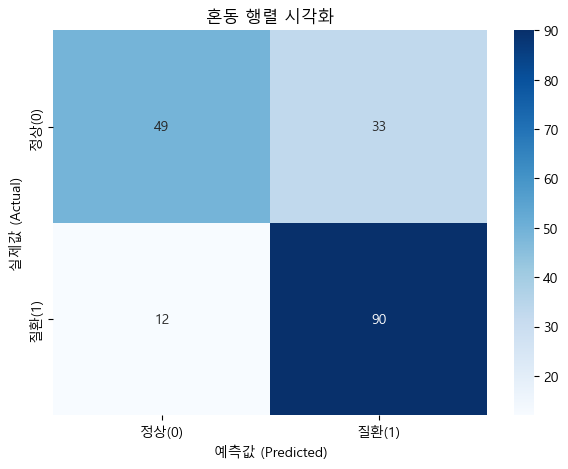

In [265]:
# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['정상(0)', '질환(1)'], 
            yticklabels=['정상(0)', '질환(1)'])
plt.title('혼동 행렬 시각화')
plt.xlabel('예측값 (Predicted)')
plt.ylabel('실제값 (Actual)')
plt.show()

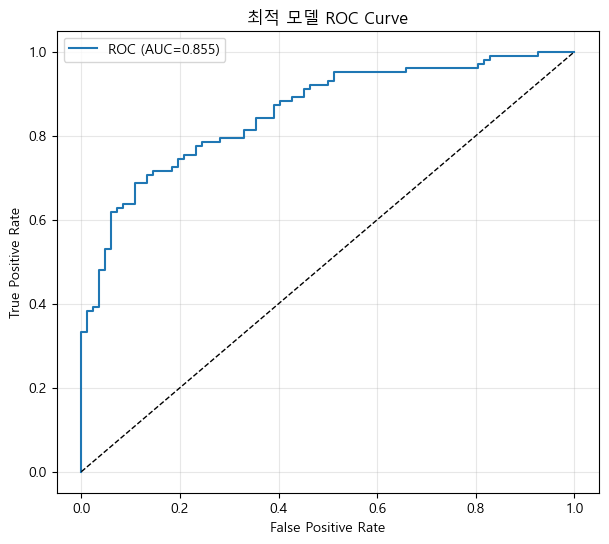

ROC-AUC: 0.8555


In [267]:
# [시각화] 최적 Logistic Regression ROC Curve

# best_lr, X_test_scaled, y_test는 GridSearchCV 셀에서 생성됨
y_prob = best_lr.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('최적 모델 ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print('ROC-AUC:', round(auc, 4))

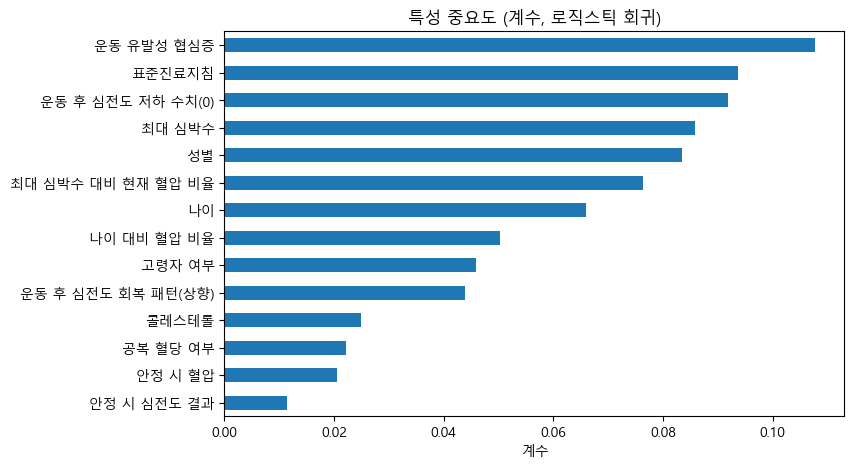

In [268]:
# 변수 중요도 (Logistic Regression: 계수 절댓값 기준)
coef_abs = pd.Series(np.abs(best_lr.coef_[0]), index=X.columns)

plt.figure(figsize=(8, 5))
coef_abs.sort_values().plot(kind='barh')
plt.title("특성 중요도 (계수, 로직스틱 회귀)")
plt.xlabel("계수")
plt.show()

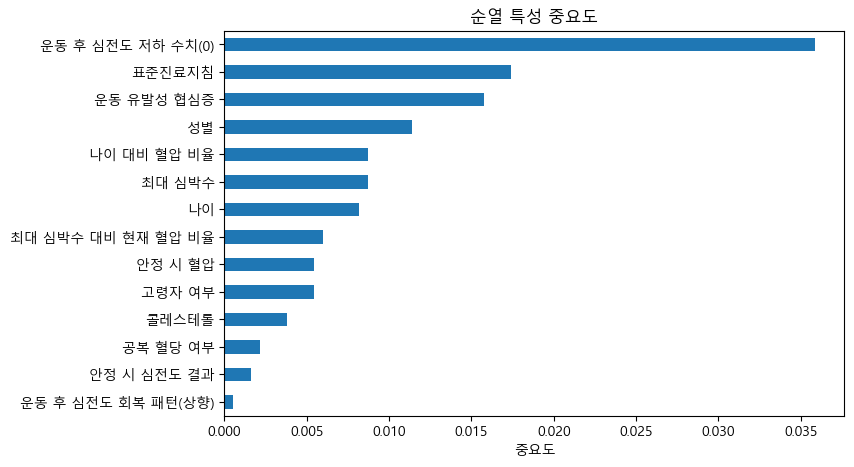

In [269]:
# Permutation Importance
perm = permutation_importance(
    best_lr, X_test_scaled, y_test,
    n_repeats=10,
    random_state=42
)
perm_importance = pd.Series(perm.importances_mean, index=X.columns)

plt.figure(figsize=(8, 5))
perm_importance.sort_values().plot(kind='barh')
plt.title("순열 특성 중요도")
plt.xlabel("중요도")
plt.show()

In [270]:
# 11. 모델 저장
joblib.dump(best_lr, "model/heart_model.pkl")
joblib.dump(scaler, "model/heart_scaler.pkl")
joblib.dump(encoders, "model/heart_encoders.pkl")

['model/heart_encoders.pkl']